# Waterfilling Levels

In [1]:
import sys
sys.path.insert(1, '../../functions')
import importlib
import numpy as np
import nbformat
import plotly.express
import plotly.express as px
import pandas as pd
import scipy.optimize as optimization
import food_bank_functions
import food_bank_bayesian
import matplotlib.pyplot as plt
import seaborn as sns
from food_bank_functions import *
from food_bank_bayesian import *
importlib.reload(food_bank_functions)

<module 'food_bank_functions' from '../../functions\\food_bank_functions.py'>

### Plotting the distribution

In [2]:
vals = np.loadtxt('../../data/fbst_synthetic/vals.csv', delimiter=",")
support = np.loadtxt('../../data/fbst_synthetic/support.csv', delimiter=",")

In [3]:
print(vals)
print(support)

[[0.0000e+00 6.0000e-05 3.7000e-04 1.5200e-03 6.9800e-03 2.2350e-02
  5.5690e-02 1.0836e-01 1.6496e-01 1.9518e-01 1.8467e-01 1.3320e-01
  7.6810e-02 3.4280e-02 1.1120e-02 3.6100e-03 7.2000e-04 1.1000e-04
  0.0000e+00 1.0000e-05 0.0000e+00]
 [0.0000e+00 6.0000e-05 2.9000e-04 1.4700e-03 4.6800e-03 1.5100e-02
  3.5470e-02 7.2450e-02 1.1898e-01 1.6151e-01 1.7701e-01 1.6124e-01
  1.2122e-01 7.2880e-02 3.6100e-02 1.5130e-02 4.8800e-03 1.2800e-03
  2.0000e-04 5.0000e-05 0.0000e+00]
 [0.0000e+00 2.0000e-05 2.1000e-04 9.9000e-04 4.0700e-03 1.4830e-02
  4.0050e-02 8.6260e-02 1.4550e-01 1.8840e-01 1.9604e-01 1.5374e-01
  9.7280e-02 4.7080e-02 1.8290e-02 5.5100e-03 1.4500e-03 2.5000e-04
  2.0000e-05 1.0000e-05 0.0000e+00]
 [0.0000e+00 1.0000e-05 9.0000e-05 5.8000e-04 2.3200e-03 7.7400e-03
  2.2910e-02 5.3240e-02 1.0150e-01 1.5670e-01 1.8415e-01 1.7959e-01
  1.3767e-01 8.5260e-02 4.3300e-02 1.7560e-02 5.6300e-03 1.5800e-03
  1.4000e-04 3.0000e-05 0.0000e+00]
 [4.0000e-05 3.8000e-04 2.4000e-03 1.365

In [4]:
print(vals.shape)

(6, 21)


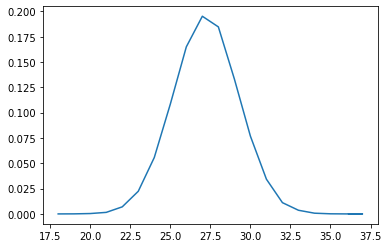

In [5]:
i=0
plt.plot(support[i], vals[i])

### Combining the Supports

In [6]:
flat_support = support.flatten()
flat_vals = vals.flatten()
print(flat_support)
print(flat_vals)

[18.         19.         20.         21.         22.         23.
 24.         25.         26.         27.         28.         29.
 30.         31.         32.         33.         34.         35.
 36.         37.         36.13448518 26.         26.9        27.8
 28.7        29.6        30.5        31.4        32.3        33.2
 34.1        35.         35.9        36.8        37.7        38.6
 39.5        40.4        41.3        42.2        43.1        42.40112915
  3.          4.          5.          6.          7.          8.
  9.         10.         11.         12.         13.         14.
 15.         16.         17.         18.         19.         20.
 21.         22.         21.00953025  3.          3.95        4.9
  5.85        6.8         7.75        8.7         9.65       10.6
 11.55       12.5        13.45       14.4        15.35       16.3
 17.25       18.2        19.15       20.1        21.05       20.78092469
  1.          1.3         1.6         1.9         2.2         2.5
  

In [7]:
new_support, inverse_index = np.unique(flat_support, return_index=True)

In [8]:
print(new_support)

[ 1.          1.3         1.6         1.9         2.          2.2
  2.5         2.8         3.          3.1         3.4         3.7
  3.95        4.          4.3         4.6         4.9         5.
  5.05262161  5.2         5.5         5.8         5.85        6.
  6.1         6.4         6.7         6.8         7.          7.75
  8.          8.7         9.          9.65       10.         10.6
 11.         11.55       12.         12.5        13.         13.45
 14.         14.4        15.         15.35       16.         16.3
 17.         17.25       18.         18.2        19.         19.15
 20.         20.1        20.1935253  20.78092469 21.         21.00953025
 21.05       22.         23.         24.         25.         26.
 26.9        27.         27.8        28.         28.7        29.
 29.6        30.         30.5        31.         31.4        32.
 32.3        33.         33.2        34.         34.1        35.
 35.         35.9        36.         36.13448518 36.8        37.
 37.7  

In [9]:
print(inverse_index)

[ 84  85  86  87 105  88  89  90  42  91  92  93  64  43  95  96  65  44
 104  98  99 100  66  45 101 102 103  67  46  68  47  69  48  70  49  71
  50  72  51  73  52  74  53  75  54  76  55  77  56  78   0  79   1  80
   2  81 125  83   3  62  82   4   5   6   7   8  22   9  23  10  24  11
  25  12  26  13  27  14  28  15  29  16  30  31  17  32  18  20  33  19
  34  35  36  37  38  39  41  40]


In [10]:
print(flat_support[84])

1.0


In [11]:
print(new_support)

[ 1.          1.3         1.6         1.9         2.          2.2
  2.5         2.8         3.          3.1         3.4         3.7
  3.95        4.          4.3         4.6         4.9         5.
  5.05262161  5.2         5.5         5.8         5.85        6.
  6.1         6.4         6.7         6.8         7.          7.75
  8.          8.7         9.          9.65       10.         10.6
 11.         11.55       12.         12.5        13.         13.45
 14.         14.4        15.         15.35       16.         16.3
 17.         17.25       18.         18.2        19.         19.15
 20.         20.1        20.1935253  20.78092469 21.         21.00953025
 21.05       22.         23.         24.         25.         26.
 26.9        27.         27.8        28.         28.7        29.
 29.6        30.         30.5        31.         31.4        32.
 32.3        33.         33.2        34.         34.1        35.
 35.         35.9        36.         36.13448518 36.8        37.
 37.7  

In [12]:
new_weights = np.zeros((6, len(new_support)))
for i in range(new_weights.shape[0]):
    print('TOWN ' + str(i))
    print(support[i,:])
    print(vals[i,:])
    for j in range(new_weights.shape[1]):
        obs = new_support[j]
        if obs in support[i, :]:
            print('found value: ' + str(obs))
            new_index = np.argmin(np.abs(new_support - obs))
            old_index = np.argmin(np.abs(support[i,:] - obs))
            new_weights[i, new_index] += vals[i, old_index]

TOWN 0
[18.         19.         20.         21.         22.         23.
 24.         25.         26.         27.         28.         29.
 30.         31.         32.         33.         34.         35.
 36.         37.         36.13448518]
[0.0000e+00 6.0000e-05 3.7000e-04 1.5200e-03 6.9800e-03 2.2350e-02
 5.5690e-02 1.0836e-01 1.6496e-01 1.9518e-01 1.8467e-01 1.3320e-01
 7.6810e-02 3.4280e-02 1.1120e-02 3.6100e-03 7.2000e-04 1.1000e-04
 0.0000e+00 1.0000e-05 0.0000e+00]
found value: 18.0
found value: 19.0
found value: 20.0
found value: 21.0
found value: 22.0
found value: 23.0
found value: 24.0
found value: 25.0
found value: 26.0
found value: 27.0
found value: 28.0
found value: 29.0
found value: 30.0
found value: 31.0
found value: 32.0
found value: 33.0
found value: 34.0
found value: 35.0
found value: 36.0
found value: 36.134485184561036
found value: 37.0
TOWN 1
[26.         26.9        27.8        28.7        29.6        30.5
 31.4        32.3        33.2        34.1        35.       

In [13]:
for i in range(6):
    print(np.sum(new_weights[i,:]))

1.0
0.9999999999999999
0.9999999999999999
0.9999999999999999
1.0
1.0


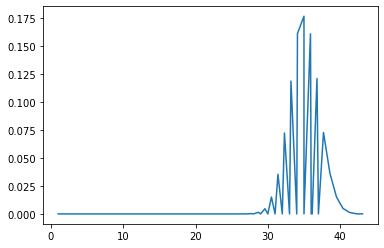

In [14]:
i = 1
plt.plot(new_support, new_weights[i,:])

In [15]:
weights = new_weights
print(weights)

[[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 6.0000e-05 0.0000e+00
  3.7000e-04 0.0000e+00 0.0000e+00 0.0000e+00 1.5200e-03 0.0000e+00
  0.0000e+00 6.9800e-03 2.2350e-02 5.5690e-02 1.0836e-01 1.6496e-01
  0.0000e+00 1.9518e-01 0.0000e+00 1.8467e-01 0.0000e+00 1.3320e-01
  0.0000e+00 7.6810e-02 0.0000e+00 3.4280e-02 0.0000e+00 1.1120e-02
  0.0000e+00 3.6100e-03 0.0000e+00 7.2000e-04 0.0000e+00 0.0000e+00
  1.1000e-04 0.0000e+00 0.0000e+00 0.0000e+00 0.

In [16]:
support = new_support
print(support)

[ 1.          1.3         1.6         1.9         2.          2.2
  2.5         2.8         3.          3.1         3.4         3.7
  3.95        4.          4.3         4.6         4.9         5.
  5.05262161  5.2         5.5         5.8         5.85        6.
  6.1         6.4         6.7         6.8         7.          7.75
  8.          8.7         9.          9.65       10.         10.6
 11.         11.55       12.         12.5        13.         13.45
 14.         14.4        15.         15.35       16.         16.3
 17.         17.25       18.         18.2        19.         19.15
 20.         20.1        20.1935253  20.78092469 21.         21.00953025
 21.05       22.         23.         24.         25.         26.
 26.9        27.         27.8        28.         28.7        29.
 29.6        30.         30.5        31.         31.4        32.
 32.3        33.         33.2        34.         34.1        35.
 35.         35.9        36.         36.13448518 36.8        37.
 37.7  

In [17]:
support.shape

(98,)

In [18]:
weights.shape

(6, 98)

### Test

In [19]:
n = 6
expected_demand = np.zeros(n)
for i in range(n):
    expected_demand[i] = np.dot(weights[i,:], support)
print(expected_demand)
max_budget = np.sum(expected_demand)

[27.21666   35.006507  12.59521   12.8319205  3.115612  11.81982  ]


In [20]:
print(max_budget)

102.58572949999996


In [21]:
np.sum(vals)

6.0

In [22]:
group_demands = np.zeros(n)
for i in range(n):
    group_demands[i] = np.random.choice(a=support, p=weights[i,:])
print(group_demands)

[23.  35.  10.  14.4  3.1 12. ]


In [23]:
print(waterfilling_waste(group_demands, max_budget))

[23.  35.  10.  14.4  3.1 12. ]


In [24]:
print(greedy(group_demands, max_budget))

[23.  35.  10.  14.4  3.1 12. ]


In [25]:
# print(constant_threshold(group_demands,max_budget,expected_demand))

In [26]:
print(waterfilling_proportional_remaining(group_demands, max_budget))

[17.09762158 17.09762158 10.         14.4         3.1        12.        ]


In [27]:
print(waterfilling_dynamic_waste(expected_demand,group_demands,max_budget))

[23.  35.  10.  14.4  3.1 12. ]


In [28]:
print(waterfilling_dynamic_full_waste(expected_demand,group_demands,max_budget))

[23.  35.  10.  14.4  3.1 12. ]


In [29]:
print(waterfilling_weights_waste(weights, support, group_demands, max_budget))

[23.  35.  10.  14.4  3.1 12. ]


In [30]:
print(waterfilling_weights_full_waste(weights, support, group_demands, max_budget))

[23.  35.  10.  14.4  3.1 12. ]


In [31]:
med = np.zeros(n)
var = np.zeros(n)
for i in range(n):
    med[i] = median(support, weights[i,:])
    var[i] = variance(support, weights[i,:])

In [32]:
print(var)

[4.06997844 4.05932936 4.06803506 4.07862911 0.25753787 4.10575517]


In [33]:
print(max_min_heuristic(group_demands, med, expected_demand, var, max_budget))

[23.  35.  10.  14.4  3.1 12. ]


# Experiments

### Calculating Fairness Statistics


In [34]:
expected_threshold = 0
for _ in range(1000):
    for i in range(n):
        group_demands[i] = np.random.choice(a=support, p=weights[i,:])
    opt = waterfilling_waste(group_demands,budget)
    expected_threshold += (1/1000)*max(opt)

In [35]:
print(expected_threshold)

1.249999999999979


In [36]:
print(support)

[ 1.          1.3         1.6         1.9         2.          2.2
  2.5         2.8         3.          3.1         3.4         3.7
  3.95        4.          4.3         4.6         4.9         5.
  5.05262161  5.2         5.5         5.8         5.85        6.
  6.1         6.4         6.7         6.8         7.          7.75
  8.          8.7         9.          9.65       10.         10.6
 11.         11.55       12.         12.5        13.         13.45
 14.         14.4        15.         15.35       16.         16.3
 17.         17.25       18.         18.2        19.         19.15
 20.         20.1        20.1935253  20.78092469 21.         21.00953025
 21.05       22.         23.         24.         25.         26.
 26.9        27.         27.8        28.         28.7        29.
 29.6        30.         30.5        31.         31.4        32.
 32.3        33.         33.2        34.         34.1        35.
 35.         35.9        36.         36.13448518 36.8        37.
 37.7  

In [37]:
num_iterations = 1000
n=6
sorted_distribution = support

In [38]:
group = np.arange(n)
group_expected_demands = expected_demand
budget = np.sum(expected_demand)
score_weights_online = np.zeros((n,num_iterations))
score_weights_full = np.zeros((n,num_iterations))
score_dynamic_online = np.zeros((n,num_iterations))
score_dynamic_full = np.zeros((n,num_iterations))
score_greedy = np.zeros((n,num_iterations))
score_adapt_threshold = np.zeros((n,num_iterations))
score_fixed_threshold = np.zeros((n,num_iterations))
score_expect_threshold = np.zeros((n, num_iterations))
score_max_min = np.zeros((n, num_iterations))

# 8 different algorithms
env = np.zeros((9,num_iterations))
po = np.zeros((9,num_iterations))
prop = np.zeros((9,num_iterations))
linf = np.zeros((9,num_iterations))
max_min = np.zeros((9, num_iterations))
for i in range(num_iterations):
    budget = np.sum(expected_demand)

        
    for j in range(n):
        group_demands[j] = np.random.choice(a=support, p=weights[j,:])
    group_median_demands = med
    group_variance = var
    

    
    opt = waterfilling_waste(group_demands,budget)


    
    weights_sol = waterfilling_weights_waste(weights, support, group_demands, budget)
    

    
    weights_full_sol = waterfilling_weights_full_waste(weights, support, group_demands, budget)
    dynamic = waterfilling_dynamic_waste(group_expected_demands,group_demands,budget)
    dynamic_full = waterfilling_dynamic_full_waste(group_expected_demands, group_demands, budget)
    proportional_threshold = waterfilling_proportional_remaining(group_demands, budget)
    greedy_sol = greedy(group_demands,budget)
    threshold = constant_threshold(group_demands,budget, budget / n)
    expect_threshold = constant_threshold(group_demands, budget, expected_threshold)
    max_min_heuristic_sol = max_min_heuristic(group_demands, group_median_demands, group_expected_demands, group_variance, budget)

    # comparing weights_online
    
    score_weights_online[:,i] = opt - weights_sol
    env[0,i] = max(0,np.amax(envy_utility(weights_sol,group_demands)))
    po[0,i] = excess(weights_sol,budget)
    prop[0,i] = np.amax(proportionality_utility(weights_sol,group_demands,budget))
    max_min[0,i] = np.min(utility_ratio(weights_sol, group_demands, budget))
    linf[0,i] = np.amax(np.abs(score_weights_online[:,i]))
    
    
    # comparing weights_full
    
    score_weights_full[:,i] = opt - weights_full_sol
    env[1,i] = max(0,np.amax(envy_utility(weights_full_sol,group_demands)))
    po[1,i] = excess(weights_full_sol,budget)
    prop[1,i] = np.amax(proportionality_utility(weights_full_sol,group_demands,budget))
    max_min[1,i] = np.min(utility_ratio(weights_full_sol, group_demands, budget))
    linf[1,i] = np.amax(np.abs(score_weights_full[:,i]))
    
    
    # comparing dynamic_online
    
    score_dynamic_online[:,i] = opt - dynamic
    env[2,i] = max(0,np.amax(envy_utility(dynamic,group_demands)))
    po[2,i] = excess(dynamic,budget)
    prop[2,i] = np.amax(proportionality_utility(dynamic,group_demands,budget))
    max_min[2,i] = np.min(utility_ratio(dynamic, group_demands, budget))
    linf[2,i] = np.amax(np.abs(score_dynamic_online[:,i]))
    
    
    # comparing dynamic_full
    
    score_dynamic_full[:,i] = opt - dynamic_full
    env[3,i] = max(0,np.amax(envy_utility(dynamic_full,group_demands)))
    po[3,i] = excess(dynamic_full,budget)
    prop[3,i] = np.amax(proportionality_utility(dynamic_full,group_demands,budget))
    max_min[3,i] = np.min(utility_ratio(dynamic_full, group_demands, budget))
    linf[3,i] = np.amax(np.abs(score_dynamic_full[:,i]))
    
    
    # comparing greedy
    
    score_greedy[:,i] = opt - greedy_sol
    env[4,i] = max(0,np.amax(envy_utility(greedy_sol,group_demands)))
    po[4,i] = excess(greedy_sol,budget)
    prop[4,i] = np.amax(proportionality_utility(greedy_sol,group_demands,budget))
    max_min[4,i] = np.min(utility_ratio(greedy_sol, group_demands, budget))
    linf[4,i] = np.amax(np.abs(score_greedy[:,i]))
    
    # comparing fixed_threshold
    
    score_fixed_threshold[:,i] = opt - threshold
    env[5,i] = max(0,np.amax(envy_utility(threshold,group_demands)))
    po[5,i] = excess(threshold,budget)
    prop[5,i] = np.amax(proportionality_utility(threshold,group_demands,budget))
    max_min[5,i] = np.min(utility_ratio(threshold, group_demands, budget))
    linf[5,i] = np.amax(np.abs(score_fixed_threshold[:,i]))    
    
    
    # comparing adaptive_threshold
    
    score_adapt_threshold[:,i] = opt - proportional_threshold
    env[6,i] = max(0,np.amax(envy_utility(proportional_threshold,group_demands)))
    po[6,i] = excess(proportional_threshold,budget)
    prop[6,i] = np.amax(proportionality_utility(proportional_threshold,group_demands,budget))
    max_min[6,i] = np.min(utility_ratio(proportional_threshold, group_demands, budget))
    linf[6,i] = np.amax(np.abs(score_adapt_threshold[:,i]))    

    # comparing expected_threshold
    
    score_expect_threshold[:,i] = opt - expect_threshold
    env[7,i] = max(0,np.amax(envy_utility(expect_threshold,group_demands)))
    po[7,i] = excess(expect_threshold,budget)
    prop[7,i] = np.amax(proportionality_utility(expect_threshold,group_demands,budget))
    max_min[7,i] = np.min(utility_ratio(expect_threshold, group_demands, budget))
    linf[7,i] = np.amax(np.abs(score_expect_threshold[:,i]))    
    

    # comparing max_min_heurstic
    
    score_max_min[:,i] = opt - max_min_heuristic_sol
    env[8,i] = max(0,np.amax(envy_utility(max_min_heuristic_sol,group_demands)))
    po[8,i] = excess(max_min_heuristic_sol,budget)
    prop[8,i] = np.amax(proportionality_utility(max_min_heuristic_sol,group_demands,budget))
    max_min[8,i] = np.min(utility_ratio(max_min_heuristic_sol, group_demands, budget))
    linf[8,i] = np.amax(np.abs(score_max_min[:,i])) 

In [39]:
print(score_weights_online)

[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-3.6874375  -3.1642705  -5.6142705  ...  0.          0.
  -1.7142705 ]
 [ 1.60303411  0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.66146741 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 2.08440339  3.1642705   4.95280309 ...  0.          0.
   1.7142705 ]]


In [40]:
score_weights_online = np.average(score_weights_online, axis=1)
score_weights_full = np.average(score_weights_full, axis=1)
score_dynamic_online = np.average(score_dynamic_online, axis=1)
score_dynamic_full = np.average(score_dynamic_full, axis=1)
score_greedy = np.average(score_greedy, axis=1)
score_adapt_threshold = np.average(score_adapt_threshold, axis=1)
score_fixed_threshold = np.average(score_fixed_threshold, axis=1)
score_expect_threshold = np.average(score_expect_threshold, axis=1)
score_max_min = np.average(score_max_min, axis=1)

env = np.average(env,axis=1)
po = np.average(po,axis=1)
prop = np.average(prop,axis=1)
linf = np.average(linf,axis=1)
max_min = np.average(max_min, axis=1)

In [41]:
print(env)

[0.06063162 0.07862914 0.09298082 0.07862074 0.14451815 0.
 0.0002546  0.         0.06503511]


In [42]:
print(po)

[ 0.38759984  0.35346294  0.47422352  0.35347182  0.29563931  4.65068263
  4.64954706 15.84762158  0.61371004]


In [43]:
print(prop)

[0.05998703 0.07852736 0.09240704 0.07852047 0.14441789 0.
 0.         0.9105851  0.06498498]


In [44]:
print(max_min)

[0.92541822 0.9043691  0.89954582 0.90437374 0.85548185 0.48985036
 0.48985036 0.03581276 0.93496489]


In [45]:
print(linf)

[ 1.45271283  1.38387557  1.72664638  1.38379038  1.82490639 16.18774285
 16.18774285 32.03536443  1.59955646]


In [46]:
print('weights_online, weights_full, dynamic_online, dynamic_full, greedy, fixed_threshold, adaptive_threshold, expected_threshold, max_min')
print('envy:')
print(env)
print('po')
print(po)
print('prop')
print(prop)
print('sum')
print(env+po+prop)
print('max_min')
print(max_min)
print('linf')
print(linf)

weights_online, weights_full, dynamic_online, dynamic_full, greedy, fixed_threshold, adaptive_threshold, expected_threshold, max_min
envy:
[0.06063162 0.07862914 0.09298082 0.07862074 0.14451815 0.
 0.0002546  0.         0.06503511]
po
[ 0.38759984  0.35346294  0.47422352  0.35347182  0.29563931  4.65068263
  4.64954706 15.84762158  0.61371004]
prop
[0.05998703 0.07852736 0.09240704 0.07852047 0.14441789 0.
 0.         0.9105851  0.06498498]
sum
[ 0.50821848  0.51061943  0.65961138  0.51061302  0.58457535  4.65068263
  4.64980166 16.75820668  0.74373013]
max_min
[0.92541822 0.9043691  0.89954582 0.90437374 0.85548185 0.48985036
 0.48985036 0.03581276 0.93496489]
linf
[ 1.45271283  1.38387557  1.72664638  1.38379038  1.82490639 16.18774285
 16.18774285 32.03536443  1.59955646]


In [47]:
data_dict = {'Group':group, 'Weights_Online': score_weights_online, 'Weights_Full':score_weights_full, 'Dynamic_Online':score_dynamic_online, 'Dynamic_Full':score_dynamic_full, 'Greedy':score_greedy, 'Adapt_Threshold': score_adapt_threshold, 'Fixed_Threshold': score_fixed_threshold, 'Expect_Threshold':score_expect_threshold, 'Max_Min_Heuristic':score_max_min}
df_uniform = pd.DataFrame(data_dict).melt(id_vars="Group")

In [48]:
df_uniform.columns

Index(['Group', 'variable', 'value'], dtype='object')

In [49]:
df_uniform.to_csv('fairness_group_by_group.csv')

Text(0.5, 0, 'Estimated Level')

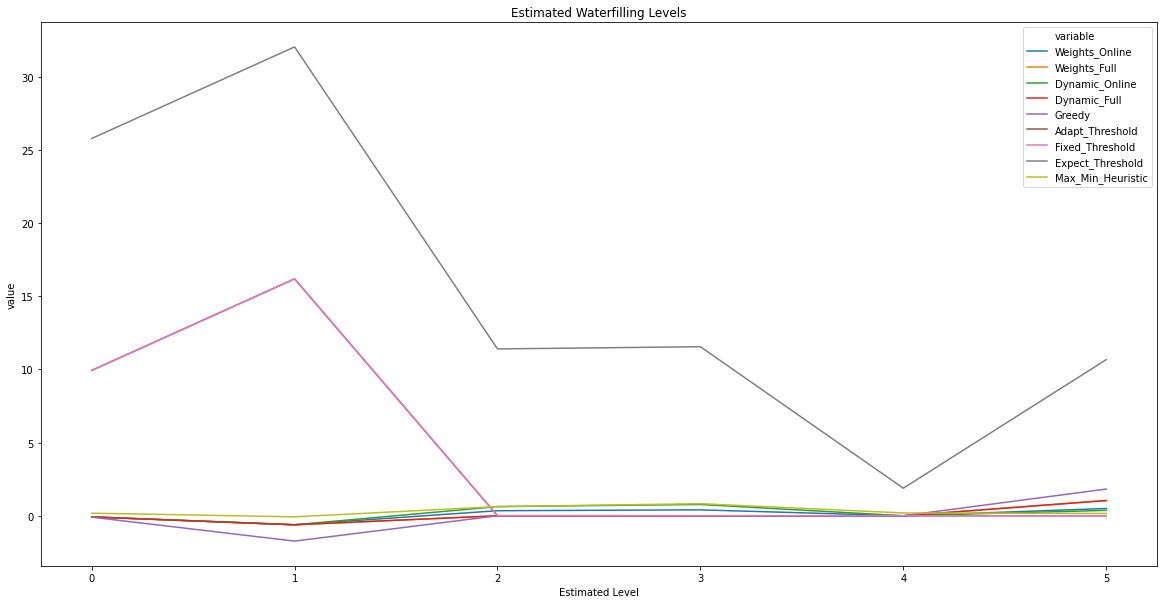

In [50]:
plt.figure(figsize=(20,10))
sns.lineplot(x='Group', y='value', hue = 'variable', data=df_uniform)
plt.title('Estimated Waterfilling Levels')
plt.xlabel('Estimated Level')